# E-commerce Sales Analysis (End-to-End)

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv(r"C:\Users\JANHAVI\Desktop\Data_Analyst_Project\sales_dataset_50k.csv")

print(df.head())

   Order_ID  Order_Date Region         Category  Product    Sales  Quantity  \
0    100000  2024-09-06  North         Clothing    Shoes   383.20         5   
1    100001  2024-10-25   West        Furniture     Desk   929.31         3   
2    100002  2024-01-21  South         Clothing    Jeans  1940.42         5   
3    100003  2024-07-14  North  Office Supplies  Stapler  1242.61         5   
4    100004  2023-07-09   East         Clothing   Jacket   112.40         2   

   Profit  
0   93.85  
1  124.00  
2  500.84  
3  252.14  
4   32.98  


In [20]:
df.head()

,Order_ID,Order_Date,Region,Category,Product,Sales,Quantity,Profit
0,100000,2024-09-06,North,Clothing,Shoes,383.20,5,93.85
1,100001,2024-10-25,West,Furniture,Desk,929.31,3,124.00
2,100002,2024-01-21,South,Clothing,Jeans,1940.42,5,500.84
3,100003,2024-07-14,North,Office Supplies,Stapler,1242.61,5,252.14
4,100004,2023-07-09,East,Clothing,Jacket,112.40,2,32.98


In [21]:
df.columns

Index(['Order_ID', 'Order_Date', 'Region', 'Category', 'Product', 'Sales',
       'Quantity', 'Profit'],
      dtype='object')

In [25]:
df.columns = df.columns.str.strip()

In [22]:
print(df.columns)

Index(['Order_ID', 'Order_Date', 'Region', 'Category', 'Product', 'Sales',
       'Quantity', 'Profit'],
      dtype='object')


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order_ID    50000 non-null  int64  
 1   Order_Date  50000 non-null  object 
 2   Region      50000 non-null  object 
 3   Category    50000 non-null  object 
 4   Product     50000 non-null  object 
 5   Sales       50000 non-null  float64
 6   Quantity    50000 non-null  int64  
 7   Profit      50000 non-null  float64
dtypes: float64(2), int64(2), object(4)
memory usage: 3.1+ MB


# Data Cleaning

# Convert Date Column

In [17]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Handling Missing Value

In [27]:
df['Profit'] = df['Profit'].fillna(df['Profit'].mean())

In [28]:
df['Profit'] = df['Profit'].fillna(df['Profit'].mean())

if 'Discount' in df.columns:
    df['Discount'] = df['Discount'].fillna(0)

In [29]:
df['Month'] = df['Order_Date'].dt.month

# Analysis

In [30]:
total_sales = df['Sales'].sum()
print("Total Sales:", total_sales)

Total Sales: 50619793.75


# Total Profit

In [32]:
total_profit = df['Profit'].sum()
print("Total Profit:", total_profit)

Total Profit: 8827280.44


# Average Sales

In [33]:
print("Average Sales:", df['Sales'].mean())

Average Sales: 1012.395875


# Category Wise Sales

In [34]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(category_sales)

Category
Office Supplies    12838059.49
Electronics        12695095.54
Clothing           12646324.86
Furniture          12440313.86
Name: Sales, dtype: float64


# Region Wise Sales

In [36]:
region_profit = df.groupby('Region')['Profit'].sum()

print(region_profit)

Region
East     2181087.43
North    2229510.34
South    2217126.38
West     2199556.29
Name: Profit, dtype: float64


# Monthly Sales Trend

In [37]:
monthly_sales = df.groupby('Month')['Sales'].sum()

print(monthly_sales)

Month
1     4272973.01
2     3989940.42
3     4264315.48
4     4239000.44
5     4265986.37
6     4120339.94
7     4209741.44
8     4290978.43
9     4209481.79
10    4331662.80
11    4182190.73
12    4243182.90
Name: Sales, dtype: float64


# Visualization

# Sales by Category

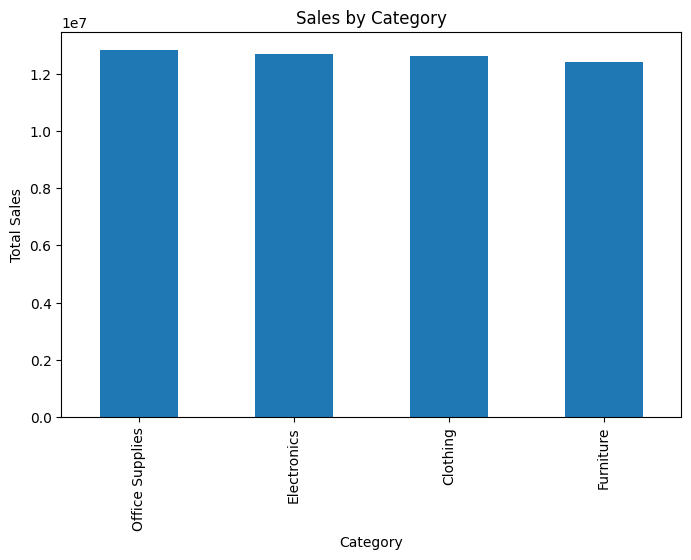

In [38]:
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

# Profit by Region

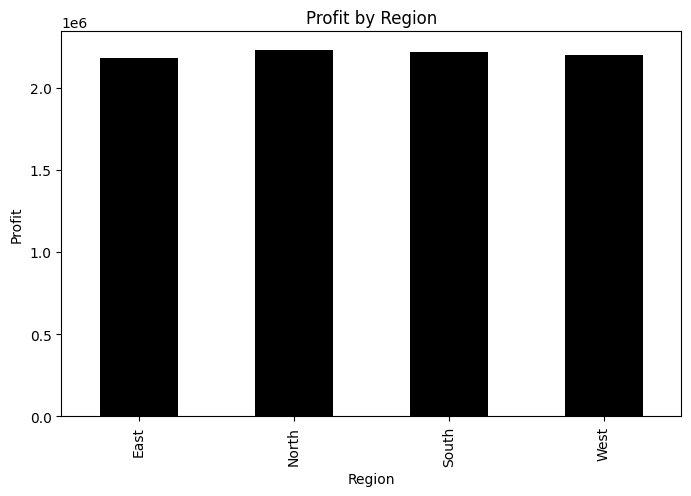

In [41]:
plt.figure(figsize=(8,5))
region_profit.plot(kind='bar', color='black')

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.show()

# Monthly Sales Trend

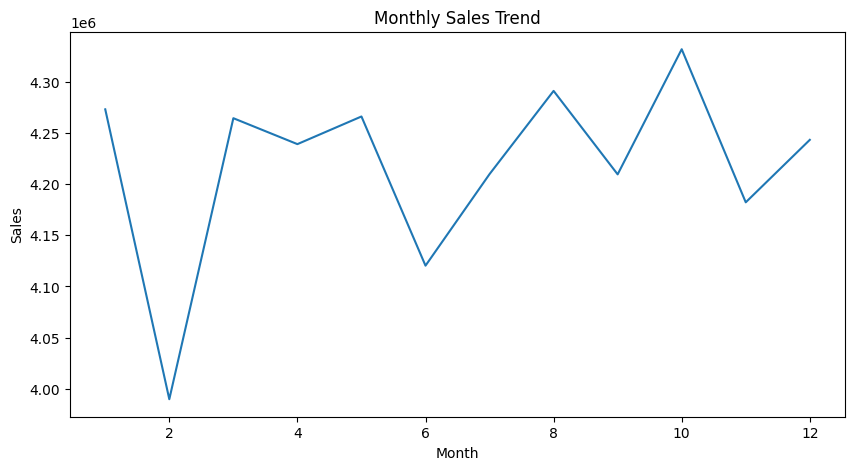

In [42]:
plt.figure(figsize=(10,5))

sns.lineplot(x=monthly_sales.index,
             y=monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

# SQL Analysis Using Python

Create SQL database.

In [47]:
import sqlite3

In [45]:
conn = sqlite3.connect("sales_database.db")

df.to_sql("sales", conn, if_exists="replace", index=False)

50000

# Total Revenue

In [46]:
query = """
SELECT SUM(Sales) as Total_Revenue
FROM sales
"""

result = pd.read_sql(query, conn)

print(result)

   Total_Revenue
0    50619793.75


# Top Selling Category

In [48]:
query = """
SELECT Category,
SUM(Sales) as Total_Sales
FROM sales
GROUP BY Category
ORDER BY Total_Sales DESC
"""

result = pd.read_sql(query, conn)

print(result)

          Category  Total_Sales
0  Office Supplies  12838059.49
1      Electronics  12695095.54
2         Clothing  12646324.86
3        Furniture  12440313.86


# Region Wise Profit

In [49]:
query = """
SELECT Region,
SUM(Profit) as Total_Profit
FROM sales
GROUP BY Region
"""

result = pd.read_sql(query, conn)

print(result)

  Region  Total_Profit
0   East    2181087.43
1  North    2229510.34
2  South    2217126.38
3   West    2199556.29


# Export Clean Data

In [50]:
df.to_csv("cleaned_sales_data.csv", index=False)